# pyXenium.pathway Tutorial

## Overview

This notebook uses the same Atera WTA breast reproducibility bundle as the cell-cell interaction walkthrough, but shifts the focus to pathway-level organization. It compares gene-topology aggregation against activity point-cloud scoring and shows how each view emphasizes different spatial programs.

## Biological question

Which pathway programs most cleanly localize to macrophage, vascular, plasma-cell, and DCIS-associated compartments, and how similar are those assignments across the two pathway topology modes?


In [1]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display


def find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Could not locate the pyXenium repository root.")


REPO_ROOT = find_repo_root()
SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

pd.set_option("display.max_columns", 20)
pd.set_option("display.max_rows", 12)


In [2]:
ATERA_DATASET_PATH = Path(
    os.environ.get(
        "PYXENIUM_ATERA_DATASET",
        r"Y:\long\10X_datasets\Xenium\Atera\WTA_Preview_FFPE_Breast_Cancer_outs",
    )
)
TBC_RESULTS_PATH = ATERA_DATASET_PATH / r"sfplot_tbc_formal_wta\results"
ARTIFACT_DIR = REPO_ROOT / "manuscript" / "atera_wta_breast_topology"
RUN_FULL_ANALYSIS = False

ATERA_DATASET_PATH, TBC_RESULTS_PATH, ARTIFACT_DIR


(WindowsPath('Y:/long/10X_datasets/Xenium/Atera/WTA_Preview_FFPE_Breast_Cancer_outs'),
 WindowsPath('Y:/long/10X_datasets/Xenium/Atera/WTA_Preview_FFPE_Breast_Cancer_outs/sfplot_tbc_formal_wta/results'),
 WindowsPath('D:/GitHub/pyXenium/manuscript/atera_wta_breast_topology'))

## Dataset

- Raw study: Atera WTA FFPE breast Xenium export.
- Versioned outputs: `manuscript/atera_wta_breast_topology/`.
- Canonical API: `compute_pathway_activity_matrix` and `pathway_topology_analysis`.

## Setup

The notebook reads the committed pathway CSVs and figures generated from the real Atera run, then keeps an optional rerun cell for regenerating the pathway bundle locally.


In [3]:
payload = json.loads((ARTIFACT_DIR / "summary.json").read_text(encoding="utf-8"))
pathway_to_cell = pd.read_csv(ARTIFACT_DIR / "pathway_to_cell.csv", index_col=0)
pathway_activity_to_cell = pd.read_csv(ARTIFACT_DIR / "pathway_activity_to_cell.csv", index_col=0)
mode_comparison = pd.read_csv(ARTIFACT_DIR / "pathway_mode_comparison.csv")

assignments = pd.DataFrame(
    {
        "pathway": pathway_to_cell.index.astype(str),
        "best_gene_topology_celltype": pathway_to_cell.idxmin(axis=1).astype(str).to_numpy(),
        "best_activity_point_cloud_celltype": pathway_activity_to_cell.idxmin(axis=1).astype(str).to_numpy(),
    }
)

display(assignments)
display(mode_comparison[["pathway", "retained_cell_count", "retained_quantile", "activity_mode"]])


,pathway,best_gene_topology_celltype,best_activity_point_cloud_celltype
0,MacrophageProgram,Macrophages,Macrophages
1,PlasmaProgram,Plasma Cells,Plasma Cells
2,VascularProgram,Endothelial Cells,Macrophages
3,BasalDCISProgram,Basal-like Structured DCIS Cells,Basal-like Structured DCIS Cells
4,ApocrineProgram,Apocrine Cells,Apocrine Cells
5,LuminalAmorphousProgram,Luminal-like Amorphous DCIS Cells,"CAFs, DCIS Associated"


,pathway,retained_cell_count,retained_quantile,activity_mode
0,ApocrineProgram,1896,0.95,intrinsic
1,BasalDCISProgram,1876,0.95,intrinsic
2,LuminalAmorphousProgram,4724,0.95,intrinsic
3,MacrophageProgram,2164,0.95,intrinsic
4,PlasmaProgram,1808,0.95,intrinsic
5,VascularProgram,3186,0.95,intrinsic


## Core workflow

The packaged Atera workflow computes both pathway views in one pass so the cell-type distances and activity-derived point clouds can be compared directly.

```python
from pyXenium.validation import run_atera_wta_breast_topology

study = run_atera_wta_breast_topology(
    dataset_root=str(ATERA_DATASET_PATH),
    tbc_results=str(TBC_RESULTS_PATH),
    output_dir="./atera_pathway_outputs",
    export_figures=True,
)

pathway_to_cell = study["pathway"]["pathway_to_cell"]
pathway_activity_to_cell = study["pathway"]["pathway_activity_to_cell"]
```

The notebook output below reuses the committed bundle to keep RTD builds fast while still showing the real pathway story.


In [4]:
if RUN_FULL_ANALYSIS and ATERA_DATASET_PATH.exists():
    from pyXenium.validation import run_atera_wta_breast_topology

    study = run_atera_wta_breast_topology(
        dataset_root=str(ATERA_DATASET_PATH),
        tbc_results=str(TBC_RESULTS_PATH),
        output_dir=str(ARTIFACT_DIR),
        export_figures=True,
    )
    display(study["pathway"]["pathway_mode_comparison"].head())
else:
    display(Markdown("Set `RUN_FULL_ANALYSIS = True` to recompute the Atera pathway bundle from the local Xenium export."))


Set `RUN_FULL_ANALYSIS = True` to recompute the Atera pathway bundle from the local Xenium export.

## Visual outputs

These heatmaps compare the primary gene-topology aggregate view with the activity point-cloud view. They answer slightly different questions: one asks which cell types are closest to a pathway's member genes in topology space, while the other asks where high-activity cells physically accumulate.


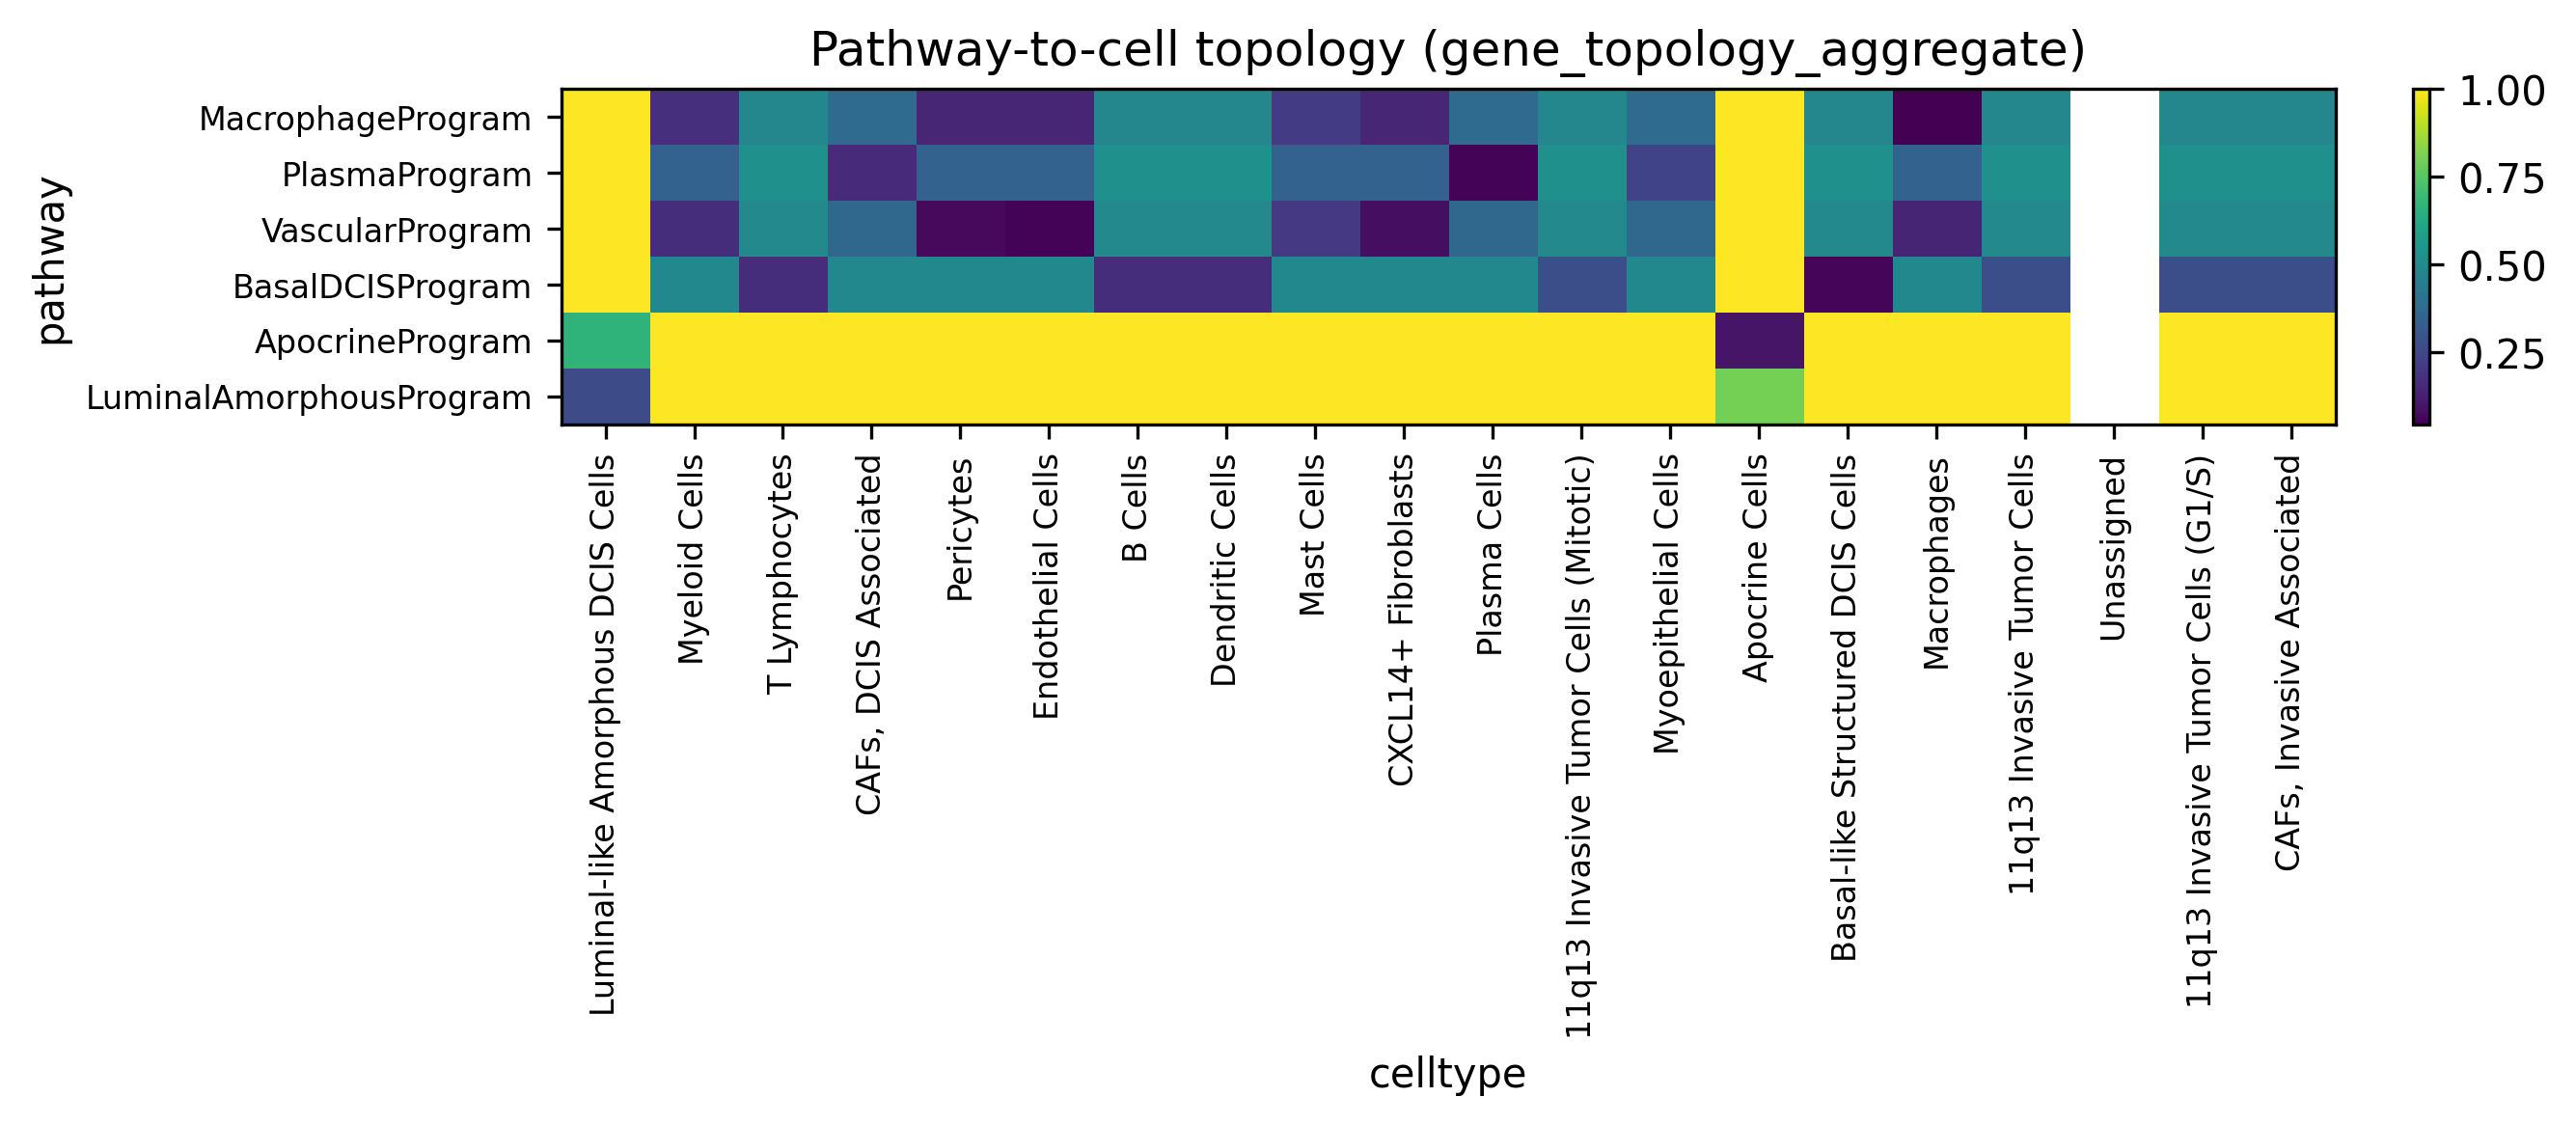

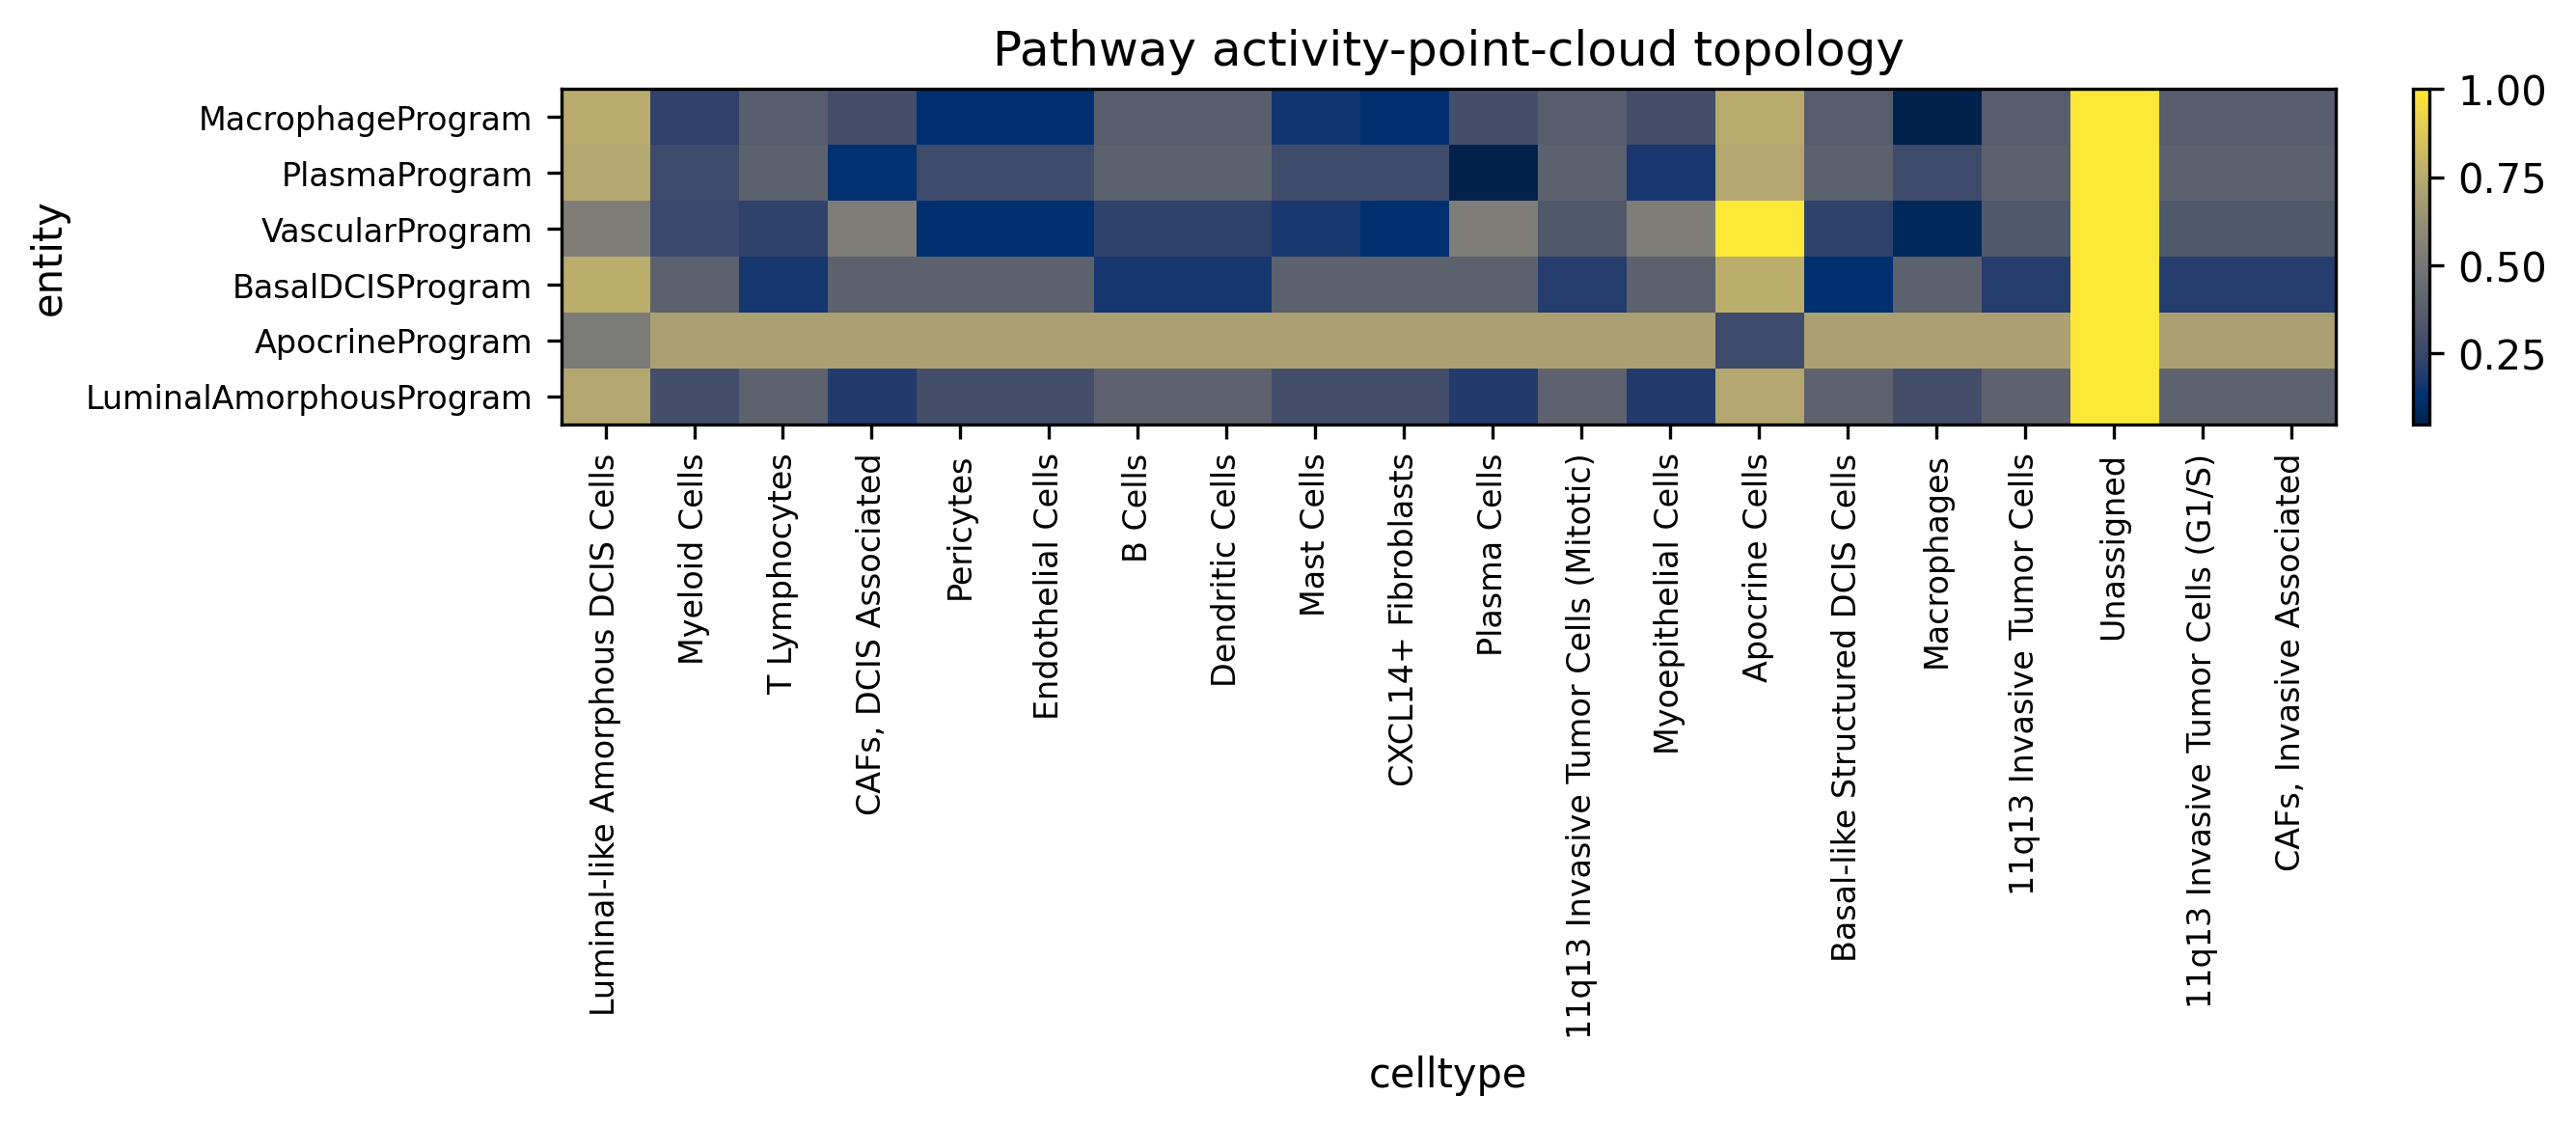

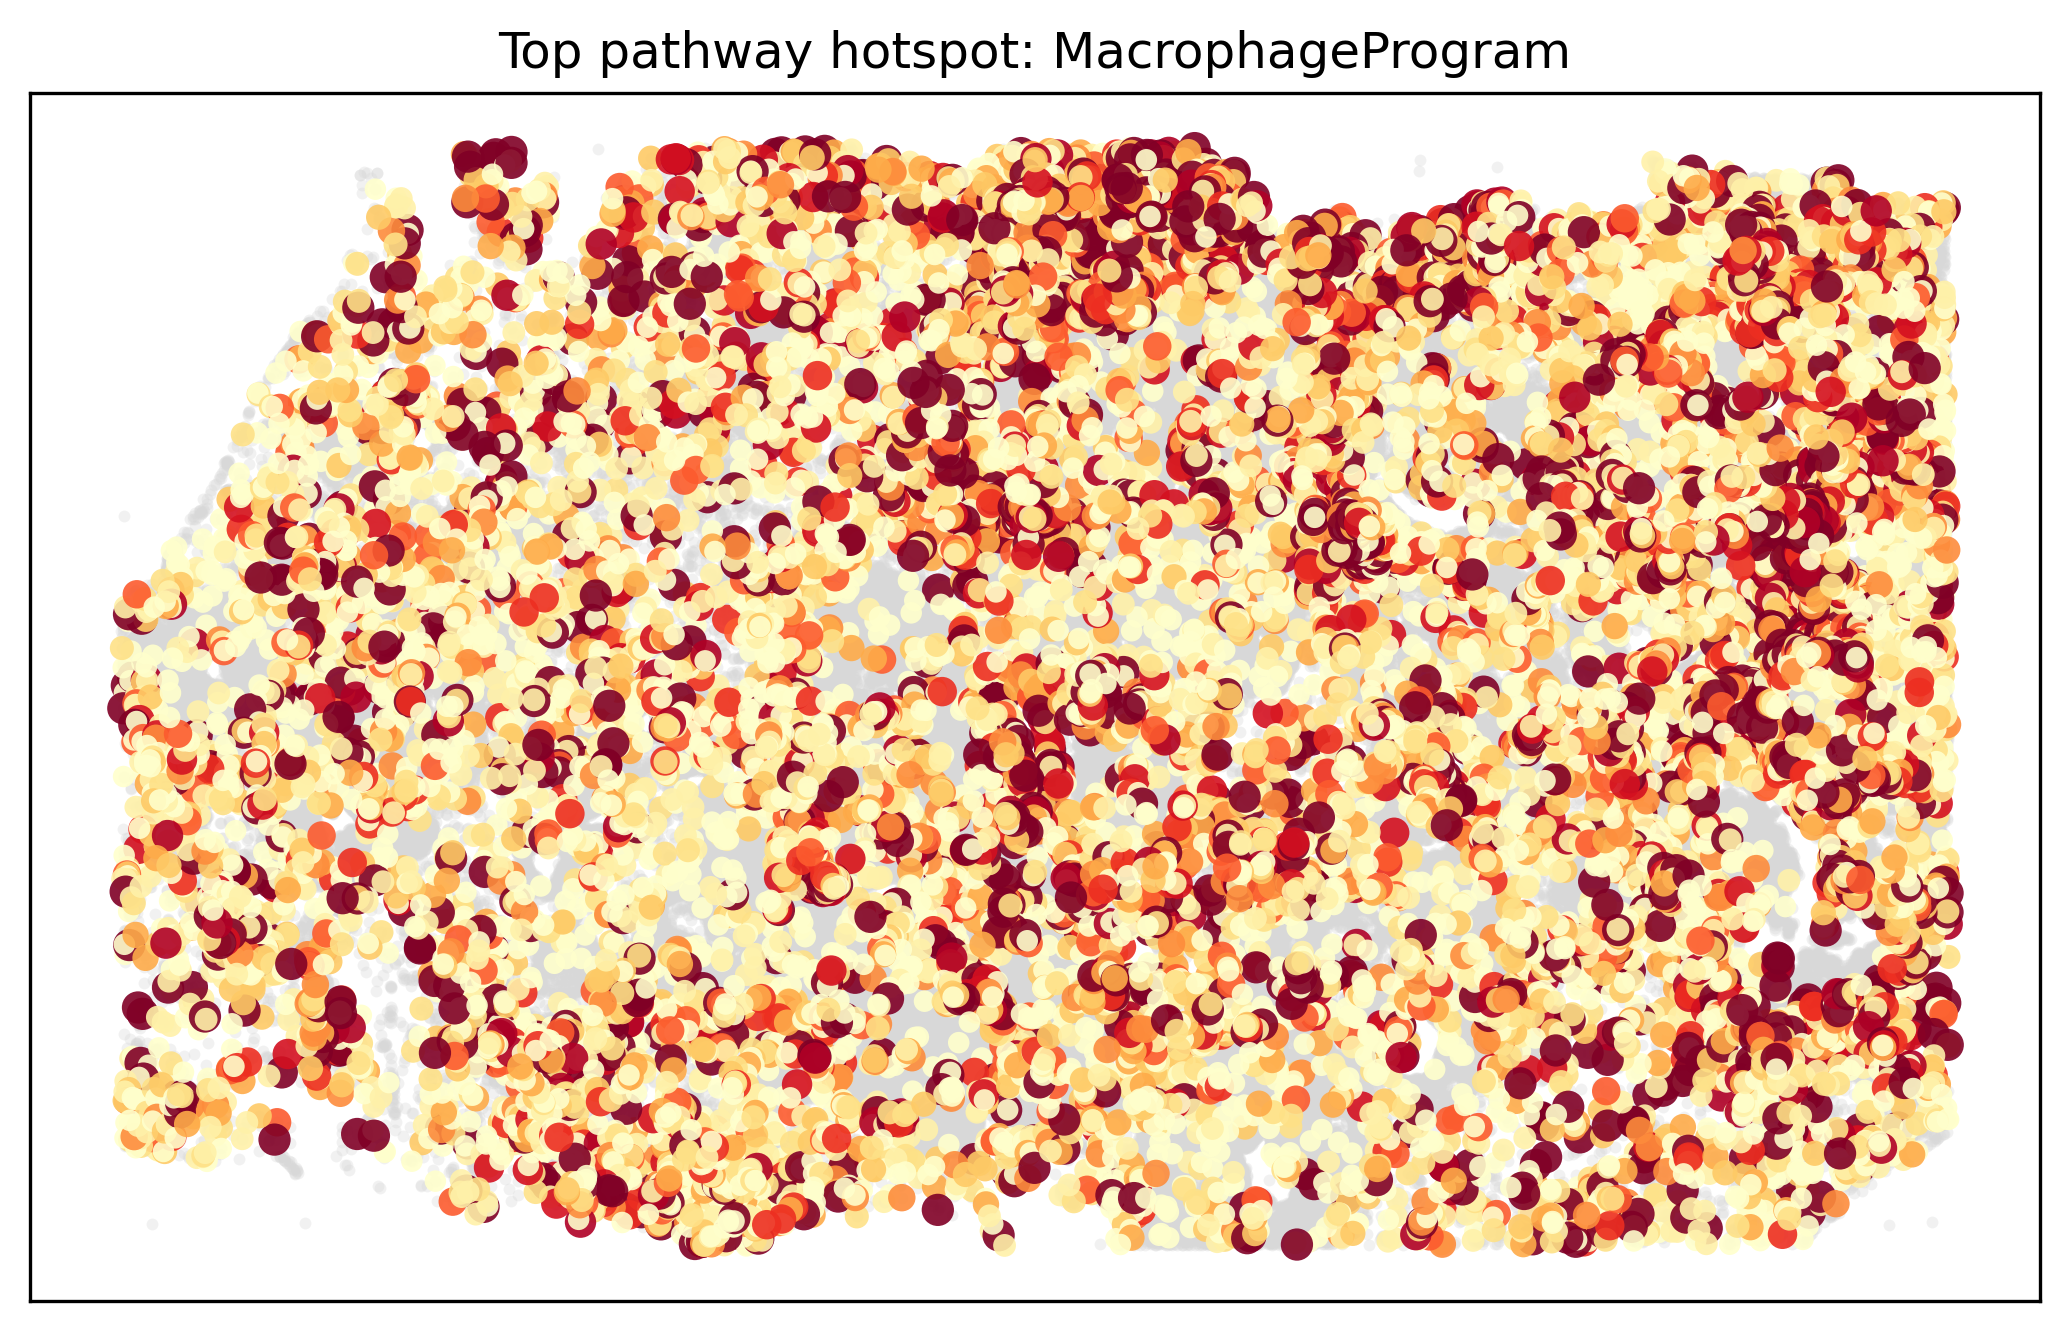

In [5]:
display(Image(filename=str(ARTIFACT_DIR / "figures" / "pathway_to_cell_heatmap.png")))
display(Image(filename=str(ARTIFACT_DIR / "figures" / "pathway_activity_to_cell_heatmap.png")))
display(Image(filename=str(ARTIFACT_DIR / "figures" / "pathway_hotspot_overlay.png")))


## Biological interpretation

The Atera pathway bundle resolves a coherent set of tissue programs: macrophage-associated genes map toward macrophage-rich compartments, vascular programs align with endothelial or perivascular niches, and DCIS-related programs remain anchored in structured epithelial regions. The activity point-cloud view is particularly useful when pathway activation is concentrated in a subset of cells rather than evenly spread across a lineage.

## Caveats

- Pathway definitions are curated smoke panels, so they are intentionally small and hypothesis-driven.
- The best cell type in the gene-topology view and the best cell type in the activity point-cloud view do not have to match.
- Retained-cell thresholds in the activity view influence hotspot shape and should be reported whenever figures are compared across studies.

## Next steps

- Revisit the `cci` notebook if you want to connect pathway programs to explicit sender-receiver pairs.
- Replace the default pathway panel with a custom pathway table when you have a cohort-specific hypothesis.
- Compare intrinsic and niche-smoothed pathway activity modes when spatial spillover is biologically plausible.
